In [54]:
import numpy as np
import matplotlib.pyplot as plt
import ortreg as odr

n = 1000
fin = 20

# Linear Par
m = 0
b = 1

# Magnitude of Noise
magn = 1

x = np.linspace(0, fin, n)
y_lin = m*x + b
noise = magn*(np.random.rand(n) - 0.5) # Generate negatives as well

y = y_lin + noise

$$
y \rightarrow r\varphi, \quad x \rightarrow z
$$

In this example.

In [55]:
# Compute translation
m, b, _ = odr.get_odr(x, y, [0.5, np.mean(y)]) # Get Shape (Should be Straight)
psi_0 = 1.5 # Around the best fit (b=0), its the slope

# Here r is the mean distance of the molecule from the center axis
psi = lambda r_m: np.deg2rad(psi_0*r_m) # The slope is based in deg - go to rads for tangent calc
b_y = lambda r_m: b - np.tan(psi(r_m))*(max(x) - min(x))/2
t_y = lambda r_m: np.tan(psi(r_m))*x + b_y(r_m)# Translation of phi, pending the b parameter, we should expect in the middle that the parameters are equal

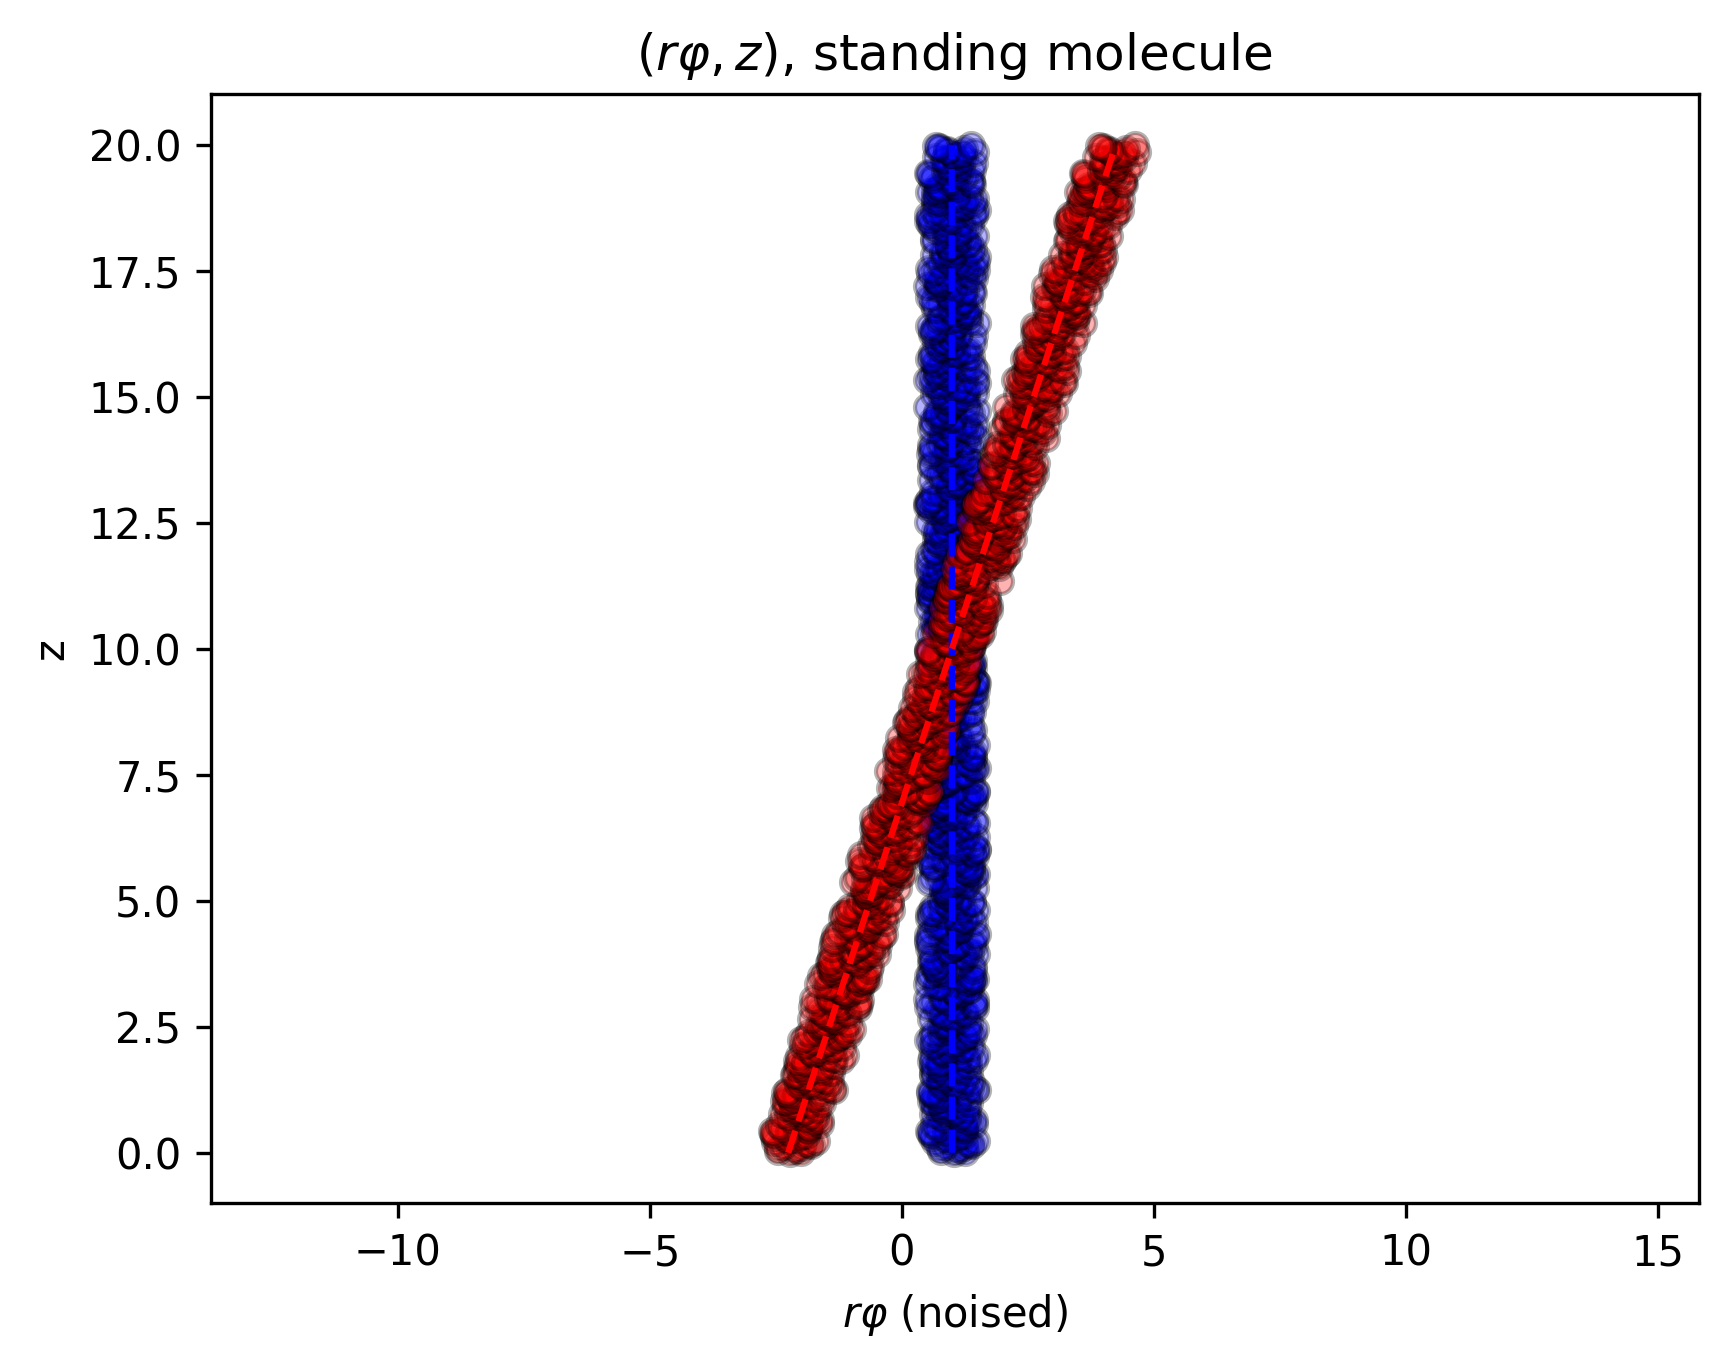

18.0


In [56]:
r_test = 12 # nm

# translation function
transl = m*x + b - t_y(r_test)

# y translated (arc)
y_t = y - transl

plt.figure(dpi=300)
plt.scatter(y, x, edgecolors='k', alpha=0.3, color='b', label='Original Data')
plt.scatter(y_t, x, edgecolors='k', alpha=0.3, color='r', label='Twisted Data')
plt.plot(m*x + b, x, linestyle='dashed', color='b', label='Original Director')
plt.plot(t_y(r_test), x, linestyle='dashed', color='r', label='Tilted (twist)')

plt.title(r'$(r\varphi, z)$, standing molecule')
plt.xlabel(r'$r\varphi$ (noised)')
plt.ylabel('z')
plt.axis('equal')
plt.show()

print(psi_0*r_test)